<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [2]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 130.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 139.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 162.4 MB/s eta 0:00:00


In [3]:
pip install --no-cache-dir seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip install numpy

In [5]:
import seaborn as sns

In [6]:
import numpy as np

#### Step 1: Load the dataset


In [131]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




In [132]:
df_age_jbsat = df[['Age', 'JobSatPoints_6']].dropna()

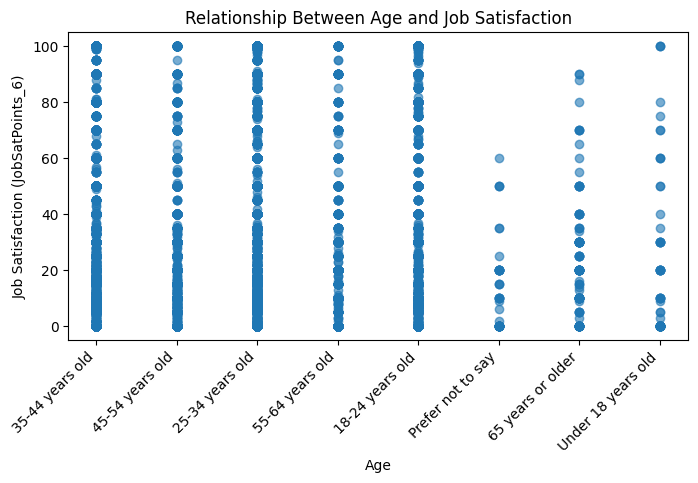

In [133]:
# Create a scatter plot with a trendline
plt.figure(figsize=(8,4))
plt.scatter(df_age_jbsat['Age'], df_age_jbsat['JobSatPoints_6'], alpha=0.6)

plt.title('Relationship Between Age and Job Satisfaction')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.

In [134]:
## Write your code here
df_ccyr_jbsat = df[['ConvertedCompYearly', 'JobSatPoints_6']]

In [135]:
# Keep data between the 1st and 99th percentile
lower_limit = df_ccyr_jbsat['ConvertedCompYearly'].quantile(0.01)
upper_limit = df_ccyr_jbsat['ConvertedCompYearly'].quantile(0.99)
df_ccyr_jbsat = df_ccyr_jbsat[(df_ccyr_jbsat['ConvertedCompYearly'] > lower_limit) & (df_ccyr_jbsat['ConvertedCompYearly'] < upper_limit)]

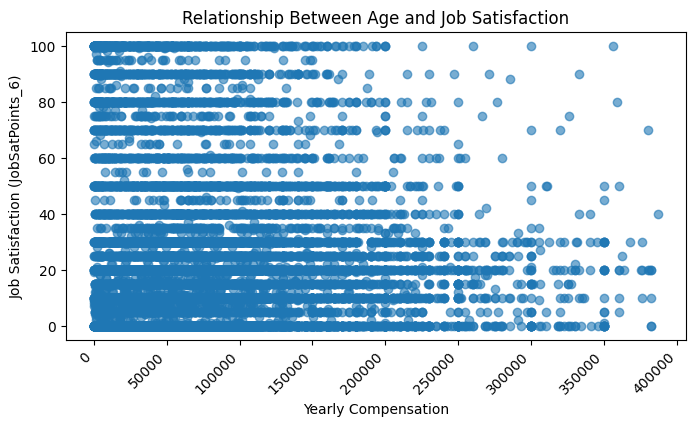

In [136]:
# Create a scatter plot with a trendline
plt.figure(figsize=(8,4))
plt.scatter(df_ccyr_jbsat['ConvertedCompYearly'], df_ccyr_jbsat['JobSatPoints_6'], alpha=0.6)
plt.title('Relationship Between Age and Job Satisfaction')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


In [137]:
#df_age_jbsat['Age'].value_counts()

In [138]:
# Define the numeric mapping (midpoints are often used for regression)
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None  # This will be dropped for regression
}

# Create a new numeric column
df_age_jbsat['Age_Numeric'] = df_age_jbsat['Age'].map(age_mapping)

In [139]:
# Drop rows where Age is missing or was 'Prefer not to say'
df_age_jbsat = df_age_jbsat.dropna(subset=['Age_Numeric', 'JobSatPoints_6'])

In [140]:
# Ensure JobSatPoints_6 is numeric
df_age_jbsat['JobSatPoints_6'] = pd.to_numeric(df_age_jbsat['JobSatPoints_6'], errors='coerce')
df_age_jbsat = df_age_jbsat.dropna(subset=['JobSatPoints_6'])

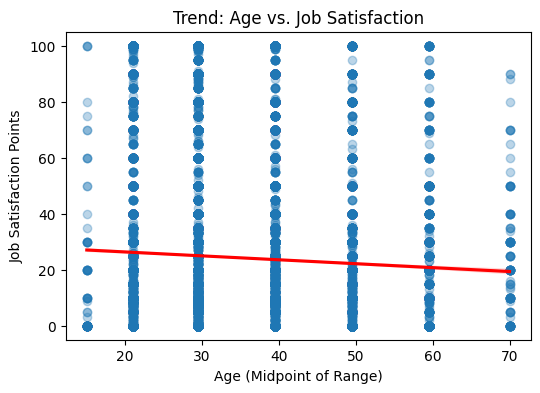

In [141]:
plt.figure(figsize=(6, 4))
sns.regplot(data=df_age_jbsat, x='Age_Numeric', y='JobSatPoints_6', 
            line_kws={"color": "red"}, scatter_kws={'alpha':0.3})

plt.title('Trend: Age vs. Job Satisfaction')
plt.xlabel('Age (Midpoint of Range)')
plt.ylabel('Job Satisfaction Points')
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [142]:
## Write your code here
df_age_exp = df[['Age','YearsCodePro']]
#df_age_exp.head()

In [143]:
df_age_exp['YearsCodePro']=pd.to_numeric(df_age_exp['YearsCodePro'], errors='coerce')
df_age_exp = df_age_exp.dropna(subset=['YearsCodePro'])

/tmp/ipykernel_301/557096095.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age_exp['YearsCodePro']=pd.to_numeric(df_age_exp['YearsCodePro'], errors='coerce')


In [144]:
#df_age_exp.head()

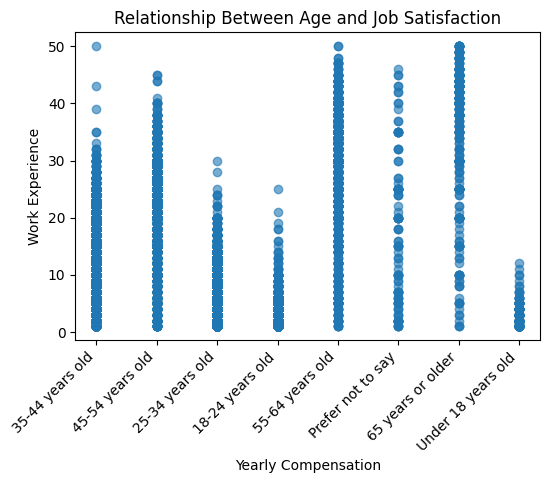

In [145]:
# Create a scatter plot with a trendline
plt.figure(figsize=(6,4))
plt.scatter(df_age_exp['Age'], df_age_exp['YearsCodePro'], alpha=0.6)
plt.title('Relationship Between Age and Job Satisfaction')
plt.xlabel('Yearly Compensation')
plt.ylabel('Work Experience')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


In [146]:
df_age_jbsat['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors = 'coerce')

In [147]:
# Keep data between the 1st and 99th percentile
lower_limit = df_age_jbsat['ConvertedCompYearly'].quantile(0.01)
upper_limit = df_age_jbsat['ConvertedCompYearly'].quantile(0.99)
df_age_jbsat = df_age_jbsat[(df_age_jbsat['ConvertedCompYearly'] > lower_limit) & (df_age_jbsat['ConvertedCompYearly'] < upper_limit)]

In [148]:
df_age_jbsat = df_age_jbsat.dropna(subset=['ConvertedCompYearly'])

In [149]:
df_age_jbsat.head()

,Age,JobSatPoints_6,Age_Numeric,ConvertedCompYearly
72,18-24 years old,65.0,21.0,7322.0
379,35-44 years old,0.0,39.5,91295.0
389,25-34 years old,20.0,29.5,110000.0
392,35-44 years old,30.0,39.5,161044.0
398,45-54 years old,30.0,49.5,195000.0


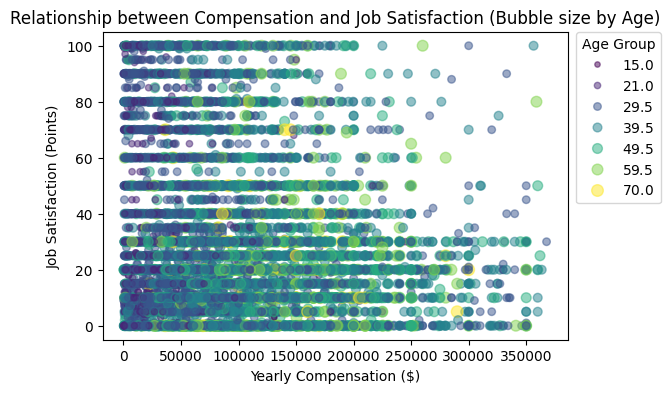

In [150]:
## Write your code here
# Generate sample data; replace this with your actual data loading
# Create the bubble plot
plt.figure(figsize=(6, 4))
scatter = plt.scatter(
    df_age_jbsat['ConvertedCompYearly'],
    df_age_jbsat['JobSatPoints_6'],
    s=df_age_jbsat['Age_Numeric'], # Scale age for better visibility of bubble sizes
    alpha=0.5,
    c=df_age_jbsat['Age_Numeric'], # Optional: color by age as well
    cmap='viridis'
)
# Add labels and title
plt.title('Relationship between Compensation and Job Satisfaction (Bubble size by Age)')
plt.xlabel('Yearly Compensation ($)')
plt.ylabel('Job Satisfaction (Points)')
# Add a legend for size
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
for handle, label in zip(handles, labels):
    # Parse the numeric value from the label (e.g., '40' from the text)
    val = float(label.replace('$\\mathdefault{', '').replace('}$', ''))
    color = scatter.cmap(scatter.norm(val))
    handle.set_color(color)
    
plt.legend(handles, labels, loc="upper right", title="Age Group", facecolor='inherit', bbox_to_anchor=(1.2, 1), borderaxespad=0.)
plt.grid(False)
plt.show() # Use plt.show() to display the plot

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


In [169]:
# 1. Prepare data (Simulated Stack Overflow Survey structure)
# Split the semicolon-separated languages into individual rows
df_exploded = df.assign(Language=df['LanguageHaveWorkedWith'].str.split(';')).explode('Language')

In [170]:
# 2. Calculate Popularity and Mean Satisfaction per Language
lang_stats = df_exploded.groupby('Language').agg(
    Popularity=('Language', 'count'),
    MeanSatisfaction=('JobSatPoints_6', 'mean')
).reset_index()

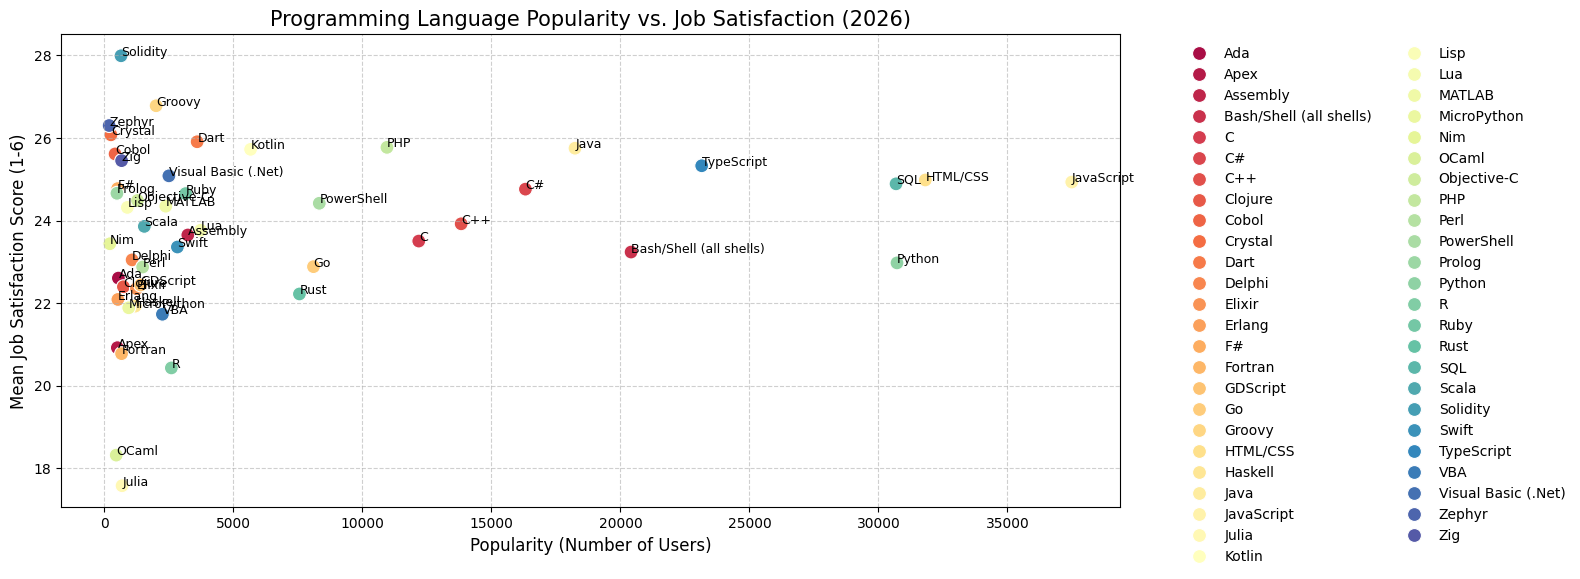

In [175]:
# 3. Create the Scatter Plot
plt.figure(figsize=(16, 6))
scatter = sns.scatterplot(data=lang_stats, x='Popularity', y='MeanSatisfaction', hue='Language', s=100, palette='Spectral')
# 4. Add Labels to Points
for i in range(lang_stats.shape[0]):
    plt.text(lang_stats.Popularity[i]+5, lang_stats.MeanSatisfaction[i], lang_stats.Language[i], fontsize=9)
# 5. Formatting
plt.title('Programming Language Popularity vs. Job Satisfaction (2026)', fontsize=15)
plt.xlabel('Popularity (Number of Users)', fontsize=12)
plt.ylabel('Mean Job Satisfaction Score (1-6)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Position legend away from the plot
plt.legend(ncol = 2, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [198]:
df_Emp_CCYr_JbSat6 = df[['ConvertedCompYearly','JobSatPoints_6','Employment']]
#df_Emp_CCYr_JbSat6.head()

In [182]:
# Ensure CompTotal is numeric
df_Emp_CCYr_JbSat6['ConvertedCompYearly'] = pd.to_numeric(df_Emp_CCYr_JbSat6['ConvertedCompYearly'], errors='coerce')
df_Emp_CCYr_JbSat6['JobSatPoints_6'] = pd.to_numeric(df_Emp_CCYr_JbSat6['JobSatPoints_6'], errors='coerce')

/tmp/ipykernel_301/3143715635.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Emp_CCYr_JbSat6['ConvertedCompYearly'] = pd.to_numeric(df_Emp_CCYr_JbSat6['ConvertedCompYearly'], errors='coerce')
/tmp/ipykernel_301/3143715635.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Emp_CCYr_JbSat6['JobSatPoints_6'] = pd.to_numeric(df_Emp_CCYr_JbSat6['JobSatPoints_6'], errors='coerce')


In [184]:
# Keep data between the 1st and 99th percentile
lower_limit = df_Emp_CCYr_JbSat6['ConvertedCompYearly'].quantile(0.01)
upper_limit = df_Emp_CCYr_JbSat6['ConvertedCompYearly'].quantile(0.99)

df_Emp_CCYr_JbSat6 = df_Emp_CCYr_JbSat6[(df_Emp_CCYr_JbSat6['ConvertedCompYearly'] > lower_limit) & (df_Emp_CCYr_JbSat6['ConvertedCompYearly'] < upper_limit)]

In [185]:
# 1. Split the strings by semicolon into lists
df_Emp_CCYr_JbSat6['Employment'] = df_Emp_CCYr_JbSat6['Employment'].str.split(';')

In [186]:
df_clean = df_Emp_CCYr_JbSat6.explode('Employment')

In [187]:
# 3. Standardize text (remove whitespace and standardize casing)
df_clean['Employment'] = df_clean['Employment'].str.strip().str.capitalize()

In [188]:
mapping = {
    'Employed, Full-Time': 'Full-time',
    'Employed, Part-Time': 'Part-time',
    'Independent Contractor, Freelancer, Or Self-Employed': 'Contractor',
    'Not Employed, But Looking For Work': 'Unemployed'
}

# Replace specific substrings or exact matches
df_clean['Employment'] = df_clean['Employment'].replace(mapping, regex=True)

In [197]:
# Drop missing values for these specific columns to clean the plot
df_clean = df_clean.dropna(subset=['Employment', 'ConvertedCompYearly','JobSatPoints_6'])
#df_clean.head()

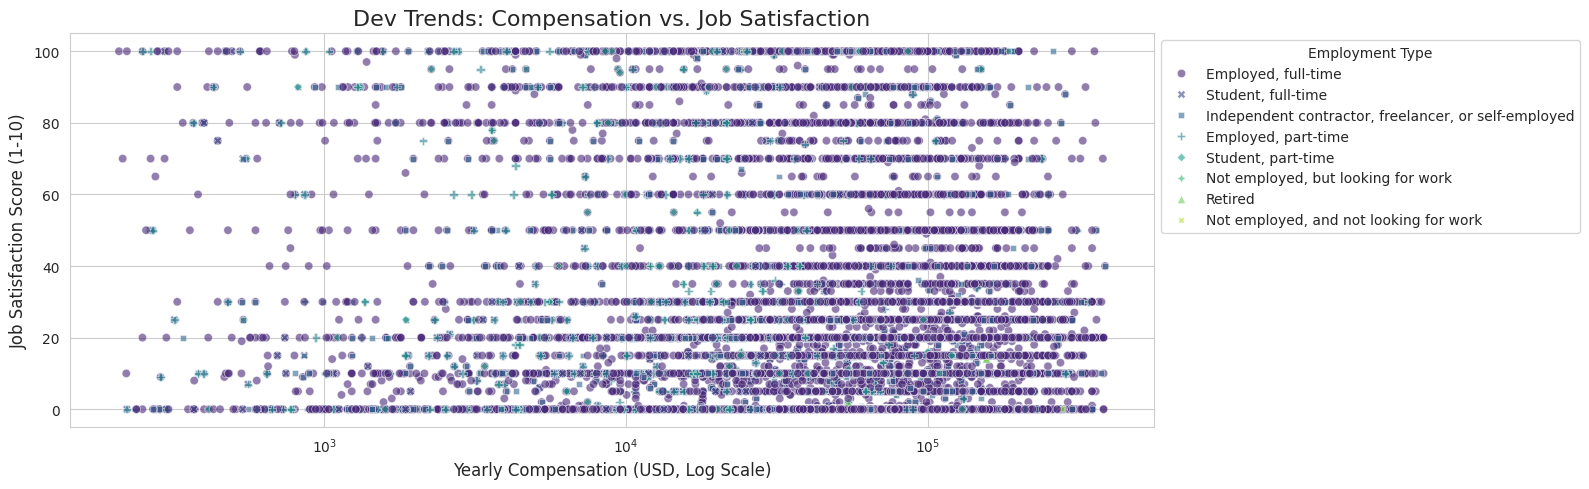

In [199]:
## Write your code here
# Visualization Code
plt.figure(figsize=(16, 5))
sns.set_style("whitegrid")
# Create the scatter plot
scatter = sns.scatterplot(data=df_clean, x='ConvertedCompYearly', y='JobSatPoints_6', hue='Employment', style='Employment', alpha=0.6, palette='viridis')
# Apply log scale to X-axis if compensation has extreme outliers
plt.xscale('log') 
# Formatting
plt.title('Dev Trends: Compensation vs. Job Satisfaction', fontsize=16)
plt.xlabel('Yearly Compensation (USD, Log Scale)', fontsize=12)
plt.ylabel('Job Satisfaction Score (1-10)', fontsize=12)
# Legend with 2 columns as requested
plt.legend(title='Employment Type', bbox_to_anchor=(1, 1), loc='upper left', ncol=1)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [200]:
df_Exp_Age_Country = df[['YearsCodePro', 'Age', 'Country']]
df_Exp_Age_Country.head()

,YearsCodePro,Age,Country
0,NaN,Under 18 years old,United States of America
1,17,35-44 years old,United Kingdom of Great Britain and Northern I...
2,27,45-54 years old,United Kingdom of Great Britain and Northern I...
3,NaN,18-24 years old,Canada
4,NaN,18-24 years old,Norway


In [201]:
## Write your code here
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None  # This will be dropped for regression
}

# Create a new numeric column
df_Exp_Age_Country['Age_Numeric'] = df_Exp_Age_Country['Age'].map(age_mapping)

/tmp/ipykernel_301/3505770895.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Exp_Age_Country['Age_Numeric'] = df_Exp_Age_Country['Age'].map(age_mapping)


In [202]:
df_Exp_Age_Country['YearsCodePro']=pd.to_numeric(df_Exp_Age_Country['YearsCodePro'], errors='coerce')
df_Exp_Age_Country = df_Exp_Age_Country.dropna(subset=['YearsCodePro', 'Age', 'Country'])

/tmp/ipykernel_301/1936838139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Exp_Age_Country['YearsCodePro']=pd.to_numeric(df_Exp_Age_Country['YearsCodePro'], errors='coerce')


/tmp/ipykernel_301/147925670.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


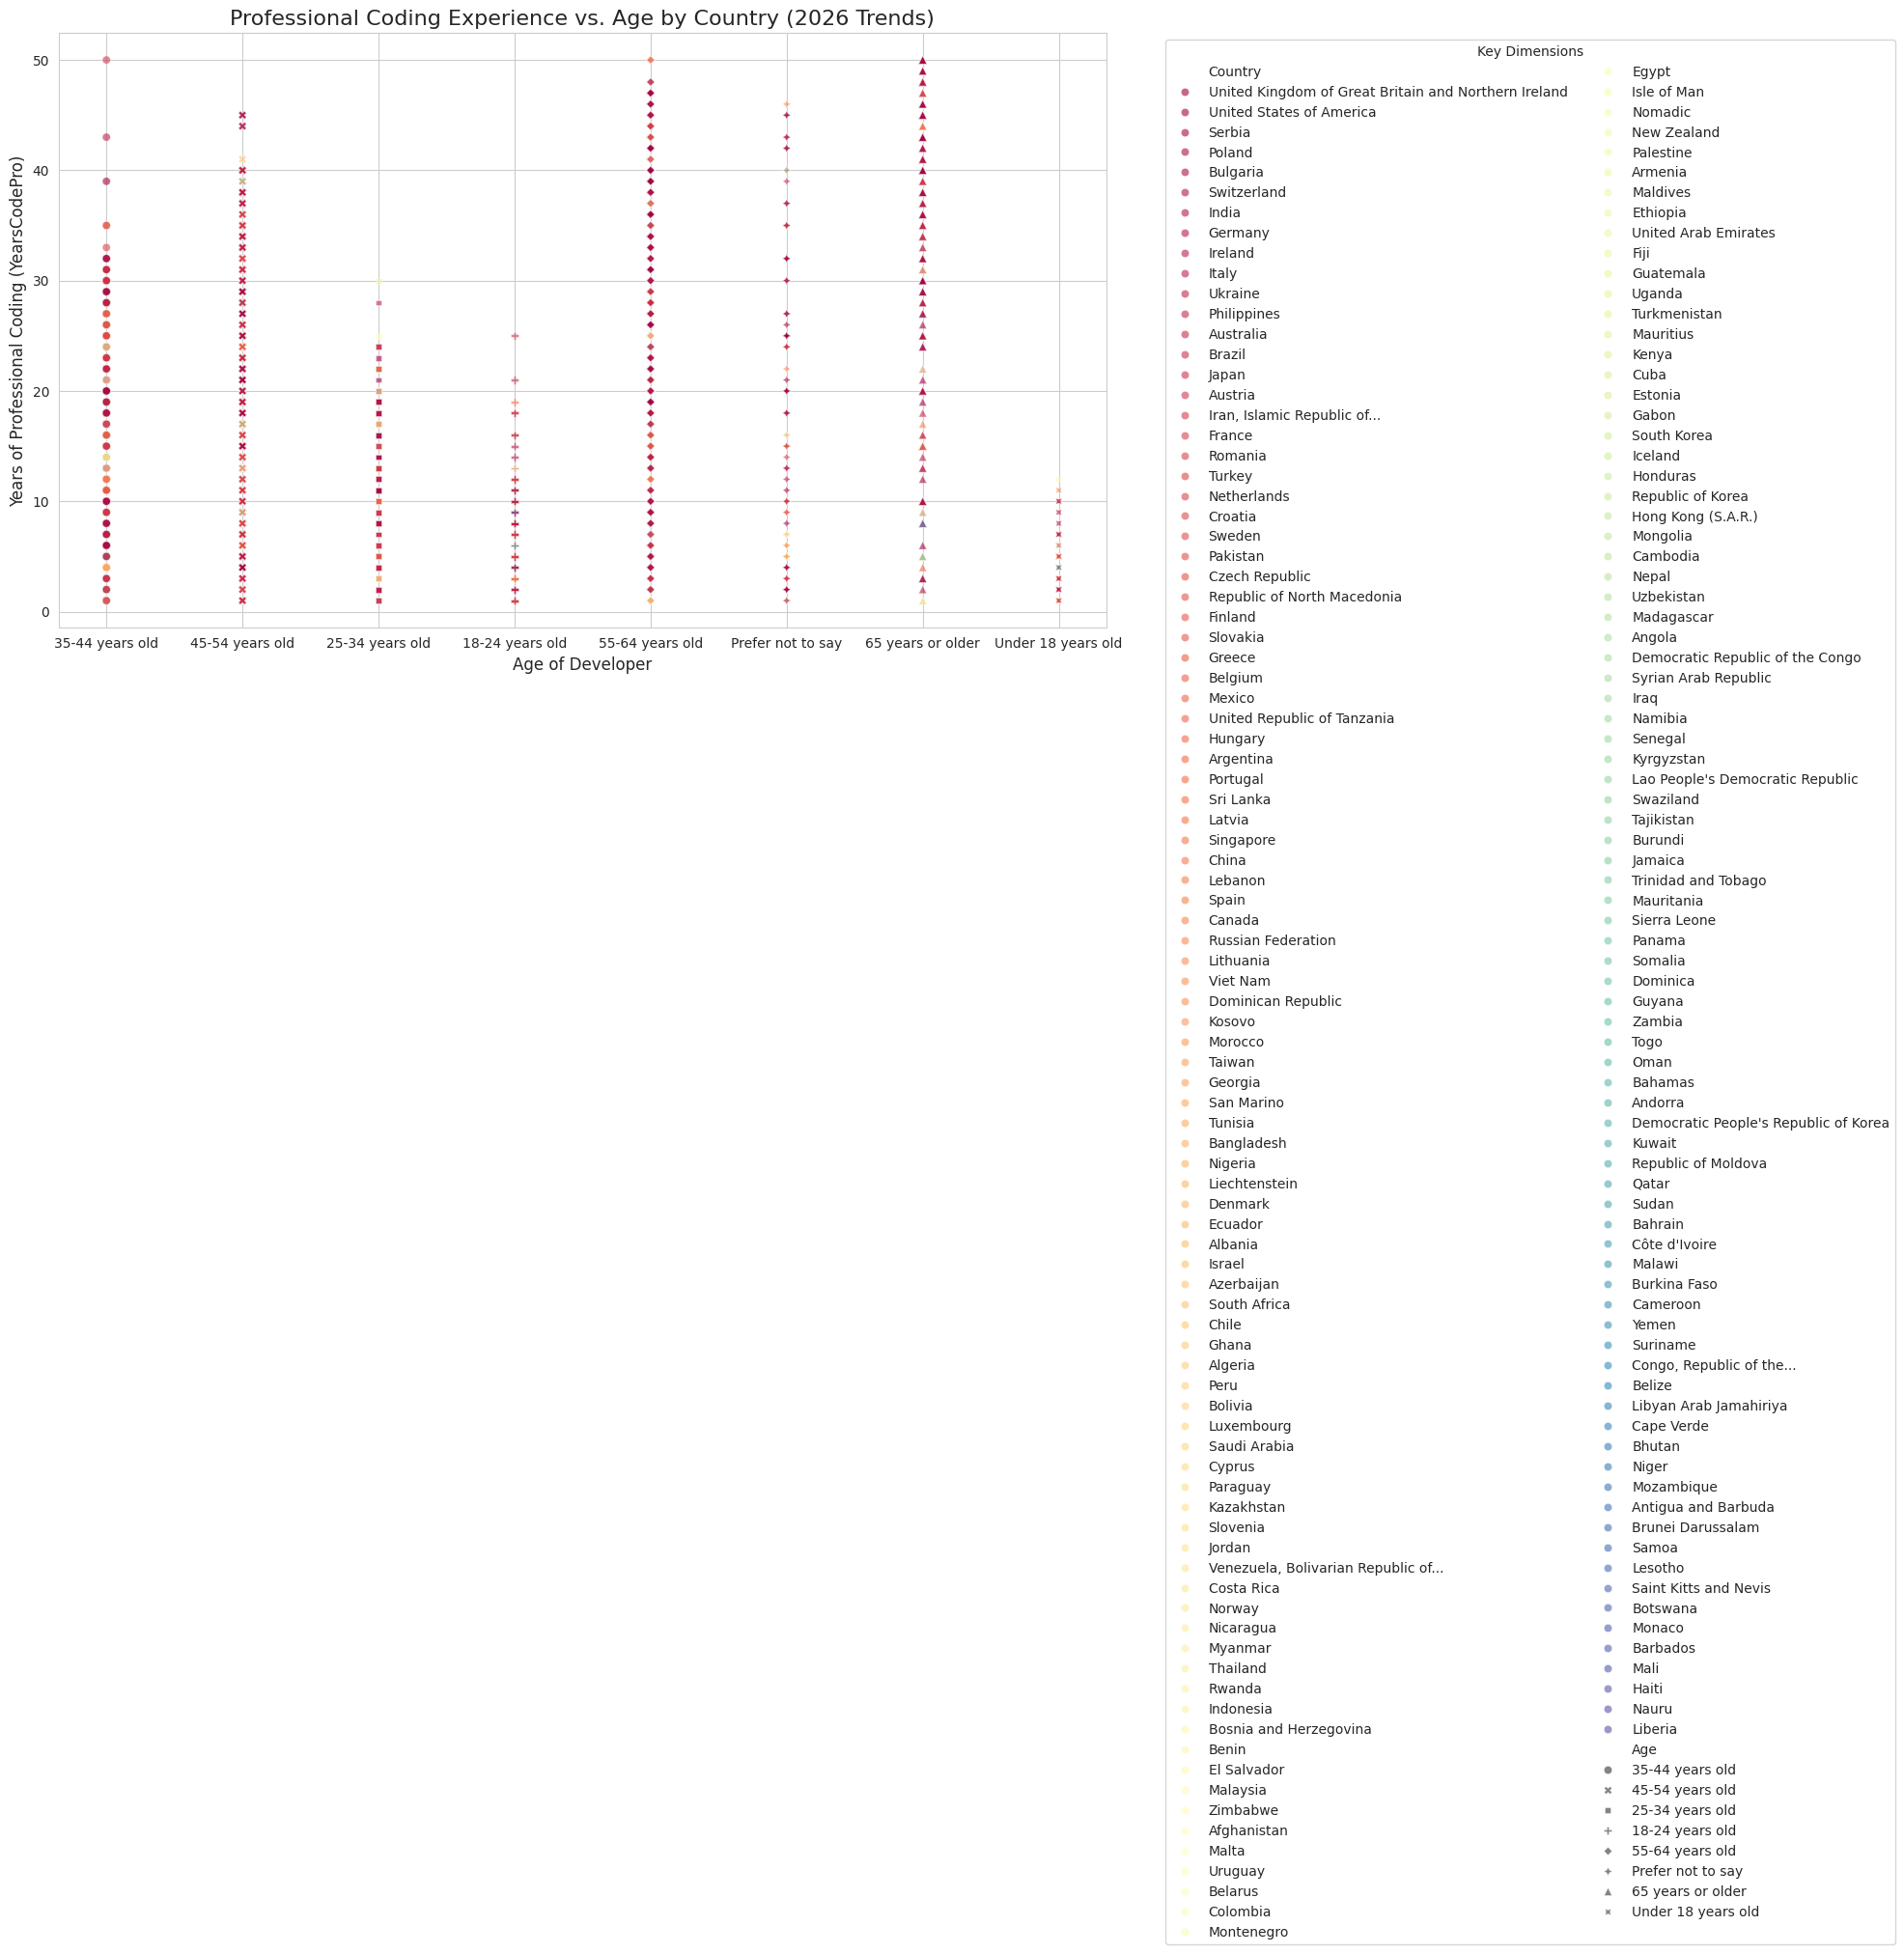

In [204]:
# Recommended setup for 2026 developer data visualization
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
scatter = sns.scatterplot(
    data=df_Exp_Age_Country, 
    x='Age', 
    y='YearsCodePro', 
    hue='Country',      # Categorical color coding
    style='Age',   # Distinct markers for age tiers
    alpha=0.6,
    palette='Spectral'
)

plt.title('Professional Coding Experience vs. Age by Country (2026 Trends)', fontsize=16)
plt.xlabel('Age of Developer', fontsize=12)
plt.ylabel('Years of Professional Coding (YearsCodePro)', fontsize=12)

# Multi-column legend for better readability
plt.legend(title='Key Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
